# Task A: Data Pre-Processing

The objective of this section is to ensure data quality before performing analysis.

The following preprocessing steps are performed:

1. Convert numeric value columns to appropriate data types.
2. Clean currency fields.
3. Identify and handle duplicate records.
4. Identify and handle missing values.
5. Standardize the use_chip values. (only three values: swipe, chip, or online.)
6. Clean city names.
7. Standardize state codes.
8. Standardize ZIP codes.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## A1. Load Datasets

Load all datasets into Pandas DataFrames, perform an initial inspection.

In [5]:
users = pd.read_csv("users_data.csv")
cards = pd.read_csv("cards_data.csv")
transactions = pd.read_csv("transactions_data.csv")

print("Users Shape:", users.shape)
print("Cards Shape:", cards.shape)
print("Transactions Shape:", transactions.shape)

Users Shape: (25, 14)
Cards Shape: (75, 13)
Transactions Shape: (50000, 12)


In [6]:
users.head()

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


In [7]:
cards.head()

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [8]:
transactions.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475509,2010-01-01 04:45:00,1718,4706,$46.21,Online Transaction,15143,ONLINE,NaN,NaN,4784,NaN
1,7475582,2010-01-01 06:03:00,511,974,$3.33,Swipe Transaction,20519,Phoenix,AZ,85015.0,5942,NaN
2,7475752,2010-01-01 06:52:00,1718,2029,$10.60,Swipe Transaction,20519,Spring Valley,CA,91977.0,5942,NaN
3,7475819,2010-01-01 07:08:00,511,1038,$21.50,Swipe Transaction,79038,Phoenix,AZ,85015.0,7538,NaN
4,7475828,2010-01-01 07:09:00,1094,3755,$80.00,Swipe Transaction,27092,Boyne City,MI,49712.0,4829,NaN


## A2. Convert Numeric Columns

Several columns contain currency symbols ($) and commas.
These columns must be converted into numeric data for analysis.

In [9]:
currency_cols_users = [
    'per_capita_income',
    'yearly_income',
    'total_debt'
]

for col in currency_cols_users:
    users[col] = (
        users[col]
        .replace(r'[\$,]', '', regex=True)
        .astype(float)
    )

cards['credit_limit'] = (
    cards['credit_limit']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

transactions['amount'] = (
    transactions['amount']
    .replace(r'[\$,]', '', regex=True)
    .astype(float)
)

In [10]:
users.dtypes

id                     int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income    float64
yearly_income        float64
total_debt           float64
credit_score           int64
num_credit_cards       int64
dtype: object

## A3. Data Hygiene

Validate that all continuous variables are stored in appropriate numeric formats.

In [11]:
numeric_columns = [
    'per_capita_income',
    'yearly_income',
    'total_debt',
    'credit_score',
    'num_credit_cards'
]

users[numeric_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   per_capita_income  25 non-null     float64
 1   yearly_income      25 non-null     float64
 2   total_debt         25 non-null     float64
 3   credit_score       25 non-null     int64  
 4   num_credit_cards   25 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 1.1 KB


## A4. Duplicate Record Check

Identify duplicate rows in each dataset and remove them if present.

In [13]:
print("Users Duplicates:", users.duplicated().sum())
print("Cards Duplicates:", cards.duplicated().sum())
print("Transactions Duplicates:", transactions.duplicated().sum())

Users Duplicates: 0
Cards Duplicates: 0
Transactions Duplicates: 0


In [15]:
users.drop_duplicates(inplace=True)
cards.drop_duplicates(inplace=True)
transactions.drop_duplicates(inplace=True)

In [16]:
print("Users Shape:", users.shape)
print("Cards Shape:", cards.shape)
print("Transactions Shape:", transactions.shape)

Users Shape: (25, 14)
Cards Shape: (75, 13)
Transactions Shape: (50000, 12)


### Observation

Duplicate records were checked and removed if present to prevent bias during analysis.

## A5. Missing Values

Identify columns with missing values and visualize their distribution.

In [17]:
print("Users Missing Values")
display(users.isnull().sum())

print("Cards Missing Values")
display(cards.isnull().sum())

print("Transactions Missing Values")
display(transactions.isnull().sum())

Users Missing Values


id                   0
current_age          0
retirement_age       0
birth_year           0
birth_month          0
gender               0
address              0
latitude             0
longitude            0
per_capita_income    0
yearly_income        0
total_debt           0
credit_score         0
num_credit_cards     0
dtype: int64

Cards Missing Values


id                       0
client_id                0
card_brand               0
card_type                0
card_number              0
expires                  0
cvv                      0
has_chip                 0
num_cards_issued         0
credit_limit             0
acct_open_date           0
year_pin_last_changed    0
card_on_dark_web         0
dtype: int64

Transactions Missing Values


id                    0
date                  0
client_id             0
card_id               0
amount                0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state     8008
zip                8358
mcc                   0
errors            49145
dtype: int64

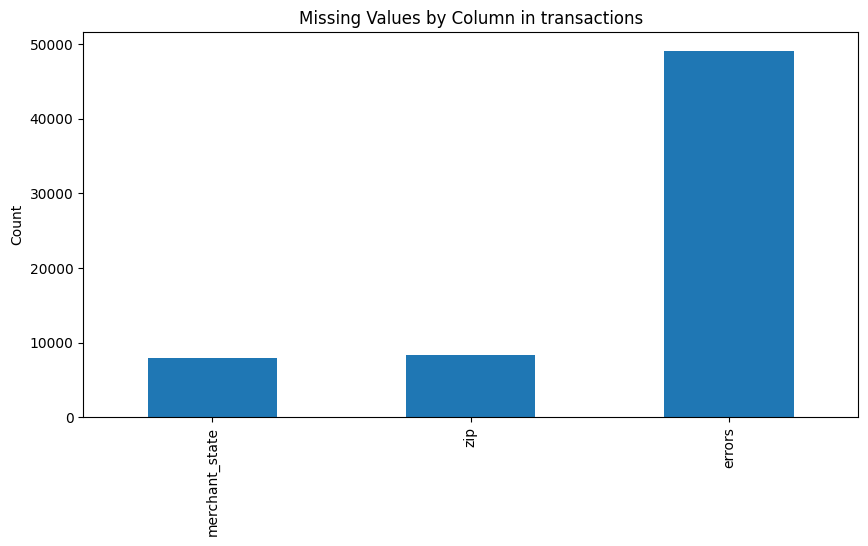

In [19]:
missing_values = transactions.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10,5))
missing_values.sort_values().plot(kind='bar')

plt.title('Missing Values by Column in transactions')
plt.ylabel('Count')
plt.show()

In [20]:
transactions['errors'] = transactions['errors'].fillna('No Error')

### Observation

Missing values were identified and handled appropriately.

For the errors column, missing values indicate that no error occurred during the transaction and were therefore replaced with "No Error".

## A6. Standardize use_chip Values

The assignment requires the use_chip column to contain only:

- chip
- swipe
- online

In [22]:
transactions['use_chip'].value_counts(dropna=False)

use_chip
Swipe Transaction     41992
Online Transaction     8008
Name: count, dtype: int64

In [23]:
transactions['use_chip'] = (
    transactions['use_chip']
    .replace({
        'Swipe Transaction': 'swipe',
        'Online Transaction': 'online',
        'Chip Transaction': 'chip'
    })
)

### Validation

In [24]:
transactions['use_chip'].value_counts(dropna= False)

use_chip
swipe     41992
online     8008
Name: count, dtype: int64

### Observation

The transaction dataset contains only two transaction modes:

1. Swipe Transactions
2. Online Transactions

No chip-based transactions were present in the dataset.

The values were standardized to maintain consistency for future analysis.

## A7. Standardize City Names

Remove extra spaces and convert city names into proper title case.

In [26]:
transactions['merchant_city'] = (
    transactions['merchant_city']
    .astype(str)
    .str.strip()
    .str.title()
)

In [27]:
transactions['merchant_city'].sample(10)

44058          Boise City
47116              Online
44071    Huntington Beach
33521           Abbeville
13401           Cleveland
22682              Tucson
18914            La Verne
40028             Pinetop
43217            New York
14336              Online
Name: merchant_city, dtype: object

## A8. Standardize State Codes

Ensure state codes are stored as two-letter uppercase abbreviations.

In [28]:
transactions['merchant_state'] = (
    transactions['merchant_state']
    .astype(str)
    .str.strip()
    .str.upper()
)

In [32]:
transactions['merchant_state'].unique()[:20]


array(['NAN', 'AZ', 'CA', 'MI', 'KY', 'LA', 'OK', 'PA', 'NY', 'WI', 'IA',
       'OH', 'AR', 'NV', 'CANADA', 'NJ', 'IN', 'WV', 'FL', 'TX'],
      dtype=object)

## A9. Standardize ZIP Codes

Convert ZIP codes into a fixed 5-digit string format while preserving leading zeros.

In [33]:
transactions['zip'] = (
    transactions['zip']
    .fillna(0)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

In [37]:
transactions['zip'].head()

0    00000
1    85015
2    91977
3    85015
4    49712
Name: zip, dtype: object

## Final Data Quality Verification

In [39]:
print(users.info())
print(cards.info())
print(transactions.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 25 non-null     int64  
 1   current_age        25 non-null     int64  
 2   retirement_age     25 non-null     int64  
 3   birth_year         25 non-null     int64  
 4   birth_month        25 non-null     int64  
 5   gender             25 non-null     object 
 6   address            25 non-null     object 
 7   latitude           25 non-null     float64
 8   longitude          25 non-null     float64
 9   per_capita_income  25 non-null     float64
 10  yearly_income      25 non-null     float64
 11  total_debt         25 non-null     float64
 12  credit_score       25 non-null     int64  
 13  num_credit_cards   25 non-null     int64  
dtypes: float64(5), int64(7), object(2)
memory usage: 2.9+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 

### Conclusion

Data preprocessing was successfully completed.

Key actions performed:
- Converted currency columns to numeric format.
- Checked and removed duplicates.
- Identified and handled missing values.
- Standardized city names, state codes, and ZIP codes.
- Prepared datasets for exploratory data analysis.

# TASK B

In [40]:
cards['card_brand'].value_counts()

card_brand
Mastercard    36
Visa          35
Discover       3
Amex           1
Name: count, dtype: int64

In [41]:
cards['card_type'].value_counts()

card_type
Debit              47
Credit             22
Debit (Prepaid)     6
Name: count, dtype: int64

In [42]:
cards['credit_limit'].describe()

count        75.000000
mean      20999.573333
std       24464.860431
min          28.000000
25%        8533.500000
50%       15400.000000
75%       25932.000000
max      132439.000000
Name: credit_limit, dtype: float64

# Task B1: Customer Card Profile

## Objective

Explore customer card characteristics across:

- Card Brand
- Card Type
- Credit Limit

Visualize the distribution and derive actionable business insights.

In [44]:
brand_counts = cards['card_brand'].value_counts()
brand_counts

card_brand
Mastercard    36
Visa          35
Discover       3
Amex           1
Name: count, dtype: int64

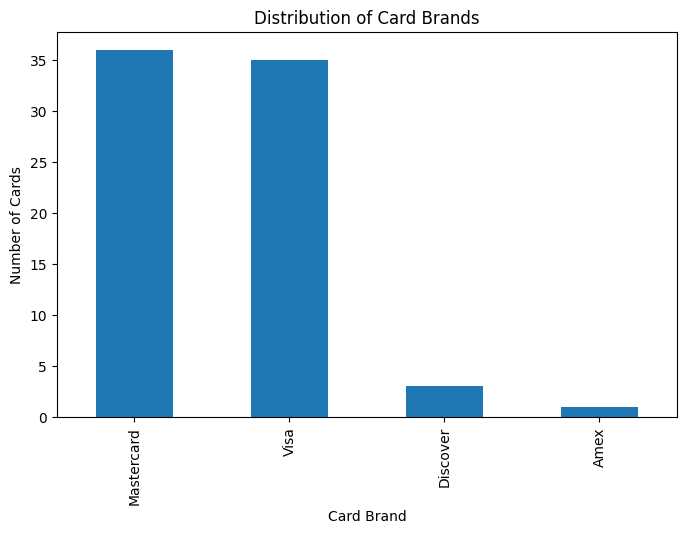

In [45]:
plt.figure(figsize=(8,5))

brand_counts.plot(kind='bar')

plt.title('Distribution of Card Brands')
plt.xlabel('Card Brand')
plt.ylabel('Number of Cards')

plt.show()

## Insights: Card Brand Distribution

- Mastercard is the most commonly issued card brand with 36 cards.
- Visa closely follows with 35 cards.
- Discover and Amex have very limited representation.

### Business Recommendation

- Since Mastercard and Visa dominate the portfolio, loyalty programs and rewards campaigns should primarily target these customer segments.
- The organization may explore partnerships to increase adoption of Discover and Amex products.

In [46]:
type_counts = cards['card_type'].value_counts()

type_counts

card_type
Debit              47
Credit             22
Debit (Prepaid)     6
Name: count, dtype: int64

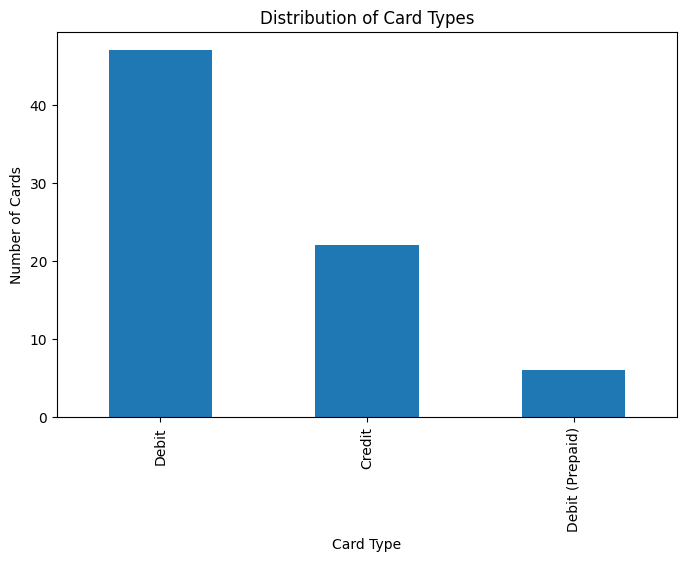

In [47]:
plt.figure(figsize=(8,5))

type_counts.plot(kind='bar')

plt.title('Distribution of Card Types')
plt.xlabel('Card Type')
plt.ylabel('Number of Cards')

plt.show()

## Insights: Card Type Distribution

- Debit cards account for the majority of issued cards.
- Credit cards represent a smaller portion of the portfolio.
- Prepaid debit cards are used by a limited number of customers.

### Business Recommendation

- Customers currently using debit cards could be targeted for credit card upgrades.
- Personalized offers and cashback incentives may encourage migration to higher-value credit products.

In [51]:
cards['credit_limit'].describe()

count        75.000000
mean      20999.573333
std       24464.860431
min          28.000000
25%        8533.500000
50%       15400.000000
75%       25932.000000
max      132439.000000
Name: credit_limit, dtype: float64

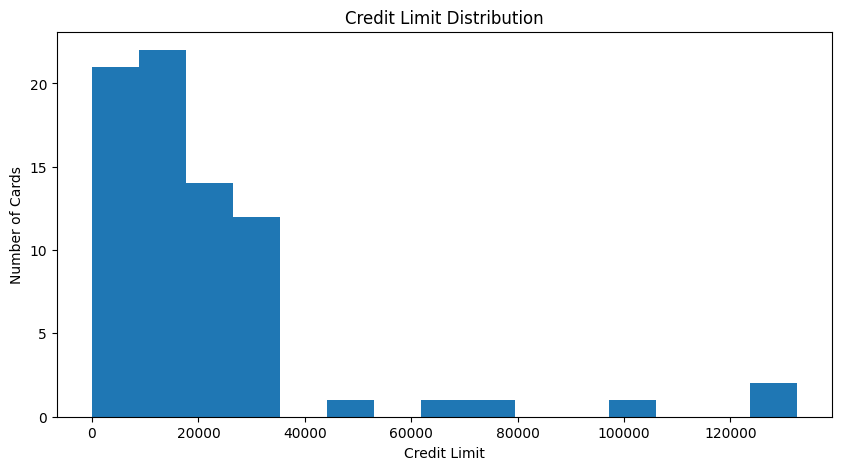

In [54]:
# HISTOGRAM

plt.figure(figsize=(10,5))

plt.hist(cards['credit_limit'], bins=15)

plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Number of Cards')

plt.show()

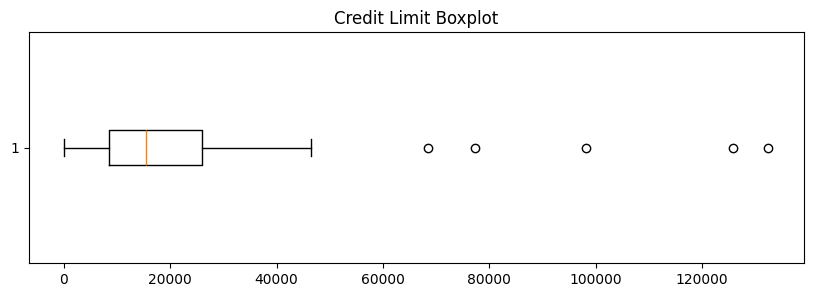

In [57]:
# BOXPLOT 
plt.figure(figsize=(10,3))

plt.boxplot(cards['credit_limit'], vert=False)

plt.title('Credit Limit Boxplot')

plt.show()

## Insights: Credit Limit

Summary Statistics:

- Average Credit Limit: approximately $21,000
- Median Credit Limit: approximately $15,400
- Maximum Credit Limit: approximately $132,439

Observations:

- The average credit limit is significantly higher than the median.
- This indicates the presence of a few customers with very high credit limits.
- The boxplot confirms the existence of outliers.

### Business Recommendation

- High-limit customers may represent premium or high-net-worth segments.
- These customers can be targeted with premium rewards, concierge services, and exclusive benefits.
- Customers with strong repayment history and good credit scores can be evaluated for credit limit increases.

In [59]:
# Card Brand vs Credit Limit

brand_limit = (
    cards
    .groupby('card_brand')['credit_limit']
    .mean()
    .sort_values(ascending=False)
)

brand_limit

card_brand
Visa          26063.971429
Mastercard    17170.250000
Discover      11933.333333
Amex           8800.000000
Name: credit_limit, dtype: float64

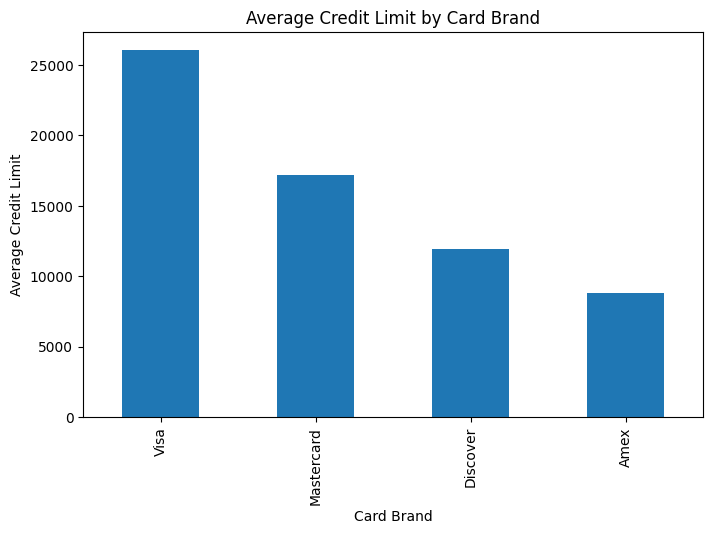

In [60]:
plt.figure(figsize=(8,5))

brand_limit.plot(kind='bar')

plt.title('Average Credit Limit by Card Brand')
plt.xlabel('Card Brand')
plt.ylabel('Average Credit Limit')

plt.show()

# Task B2: Explore Transactions

## Objective

Analyze transaction behavior by answering the following questions:

1. What is the time frame of the collected data?
2. Which client has spent the most amount?
3. What are the highest and lowest transaction amounts?
4. How are transaction amounts distributed across use_chip categories?
5. Extract insights and business recommendations.

In [61]:
transactions['date'].min(), transactions['date'].max()

('2010-01-01 04:45:00', '2012-10-29 12:55:00')

In [62]:
transactions['amount'].describe()

count    50000.000000
mean        51.639874
std        108.735885
min       -500.000000
25%         13.200000
50%         35.390000
75%         74.962500
max       6820.200000
Name: amount, dtype: float64

In [63]:
transactions['date'] = pd.to_datetime(transactions['date'])

start_date = transactions['date'].min()
end_date = transactions['date'].max()

print("Start Date:", start_date)
print("End Date:", end_date)

print("Duration:", end_date - start_date)

Start Date: 2010-01-01 04:45:00
End Date: 2012-10-29 12:55:00
Duration: 1032 days 08:10:00


## Insight: Data Collection Period

The transaction dataset spans from January 2010 to October 2012.

This provides nearly three years of customer spending behavior, allowing reliable trend analysis and customer profiling.

In [64]:
client_spend = (
    transactions
    .groupby('client_id')['amount']
    .sum()
    .sort_values(ascending=False)
)

client_spend.head()

client_id
708     326179.31
1116    293318.64
511     285794.61
825     259484.68
1164    255902.02
Name: amount, dtype: float64

In [65]:
top_client = client_spend.idxmax()
top_spend = client_spend.max()

print("Top Client:", top_client)
print("Total Spend:", round(top_spend, 2))

Top Client: 708
Total Spend: 326179.31


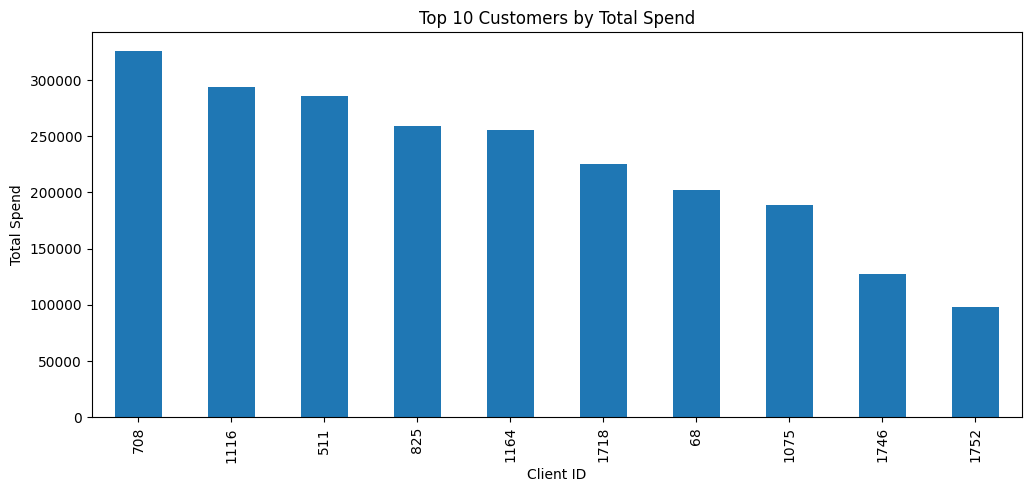

In [66]:
plt.figure(figsize=(12,5))

client_spend.head(10).plot(kind='bar')

plt.title('Top 10 Customers by Total Spend')
plt.xlabel('Client ID')
plt.ylabel('Total Spend')

plt.show()

## Insight: Customer Spending

A small number of customers contribute significantly more spending than others.

These customers represent high-value segments and may be suitable candidates for premium banking products and loyalty programs.

In [68]:
highest_transaction = transactions['amount'].max()
lowest_transaction = transactions['amount'].min()

print("Highest Transaction:", highest_transaction)
print("Lowest Transaction:", lowest_transaction)

Highest Transaction: 6820.2
Lowest Transaction: -500.0


In [69]:
transactions.groupby('use_chip')['amount'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

,count,mean,median,min,max
use_chip,,,,,
online,8008,54.764608,37.635,-494.0,3750.6
swipe,41992,51.043978,34.350,-500.0,6820.2


<Figure size 800x500 with 0 Axes>

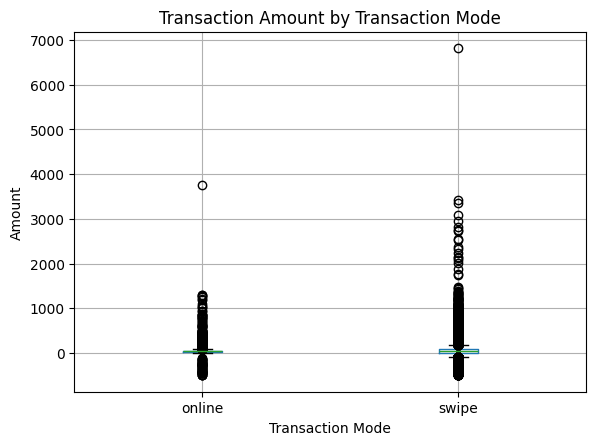

In [70]:
plt.figure(figsize=(8,5))

transactions.boxplot(
    column='amount',
    by='use_chip'
)

plt.title('Transaction Amount by Transaction Mode')
plt.suptitle('')

plt.xlabel('Transaction Mode')
plt.ylabel('Amount')

plt.show()

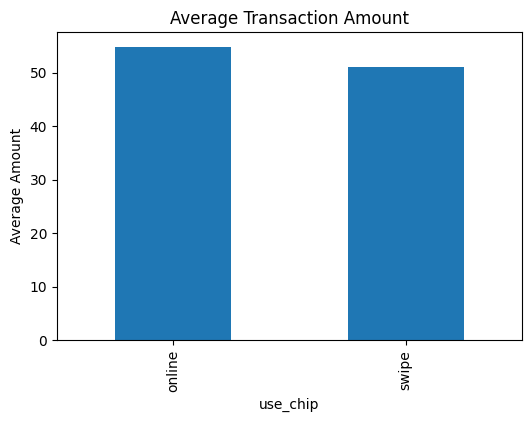

In [71]:
avg_amount = (
    transactions
    .groupby('use_chip')['amount']
    .mean()
)

plt.figure(figsize=(6,4))

avg_amount.plot(kind='bar')

plt.title('Average Transaction Amount')
plt.ylabel('Average Amount')

plt.show()

# Task B3: Customer Spend Profile vs Credit Health

## Objective

Analyze the relationship between customer spending behavior and financial health indicators.

Metrics to be computed:

- Total Spend
- Average Ticket Size
- Transaction Count
- Monthly Transaction Frequency

Financial Variables:

- Credit Score
- Yearly Income
- Total Debt
- Number of Credit Cards

In [76]:
transactions['date'] = pd.to_datetime(transactions['date'])

customer_spend = (
    transactions
    .groupby('client_id')
    .agg(
        total_spend=('amount','sum'),
        avg_ticket_size=('amount','mean'),
        transaction_count=('amount','count')
    )
    .reset_index()
)

customer_spend.head()

,client_id,total_spend,avg_ticket_size,transaction_count
0,68,202013.82,57.098310,3538
1,153,70806.08,55.447204,1277
2,511,285794.61,43.646092,6548
3,708,326179.31,132.917404,2454
4,825,259484.68,81.088962,3200


In [77]:
transactions['year_month'] = (
    transactions['date']
    .dt.to_period('M')
)

monthly_frequency = (
    transactions
    .groupby('client_id')['year_month']
    .nunique()
    .reset_index()
)

monthly_frequency.columns = [
    'client_id',
    'monthly_frequency'
]

monthly_frequency.head()

,client_id,monthly_frequency
0,68,34
1,153,34
2,511,34
3,708,34
4,825,34


In [78]:
customer_profile = (
    customer_spend
    .merge(
        monthly_frequency,
        on='client_id',
        how='left'
    )
)

customer_profile.head()

,client_id,total_spend,avg_ticket_size,transaction_count,monthly_frequency
0,68,202013.82,57.098310,3538,34
1,153,70806.08,55.447204,1277,34
2,511,285794.61,43.646092,6548,34
3,708,326179.31,132.917404,2454,34
4,825,259484.68,81.088962,3200,34


In [79]:
customer_profile = (
    customer_profile
    .merge(
        users[
            [
                'id',
                'credit_score',
                'yearly_income',
                'total_debt',
                'num_credit_cards'
            ]
        ],
        left_on='client_id',
        right_on='id',
        how='left'
    )
)

customer_profile.head()

,client_id,total_spend,avg_ticket_size,transaction_count,monthly_frequency,id,credit_score,yearly_income,total_debt,num_credit_cards
0,68,202013.82,57.098310,3538,34,68,704,41997.0,0.0,3
1,153,70806.08,55.447204,1277,34,153,660,27484.0,16803.0,4
2,511,285794.61,43.646092,6548,34,511,661,35602.0,55369.0,5
3,708,326179.31,132.917404,2454,34,708,722,249925.0,202328.0,4
4,825,259484.68,81.088962,3200,34,825,787,59696.0,127613.0,5


In [80]:
correlation_columns = [
    'total_spend',
    'avg_ticket_size',
    'transaction_count',
    'monthly_frequency',
    'credit_score',
    'yearly_income',
    'total_debt',
    'num_credit_cards'
]

corr_matrix = customer_profile[
    correlation_columns
].corr()

corr_matrix

,total_spend,avg_ticket_size,transaction_count,monthly_frequency,credit_score,yearly_income,total_debt,num_credit_cards
total_spend,1.000000,0.635766,0.527370,NaN,0.021342,0.541089,0.363692,0.251800
avg_ticket_size,0.635766,1.000000,-0.276390,NaN,-0.016571,0.856931,0.733904,0.096460
transaction_count,0.527370,-0.276390,1.000000,NaN,0.007086,-0.170930,-0.210101,0.165665
monthly_frequency,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_score,0.021342,-0.016571,0.007086,NaN,1.000000,0.017624,0.044961,-0.040426
yearly_income,0.541089,0.856931,-0.170930,NaN,0.017624,1.000000,0.739717,-0.046947
total_debt,0.363692,0.733904,-0.210101,NaN,0.044961,0.739717,1.000000,-0.134116
num_credit_cards,0.251800,0.096460,0.165665,NaN,-0.040426,-0.046947,-0.134116,1.000000


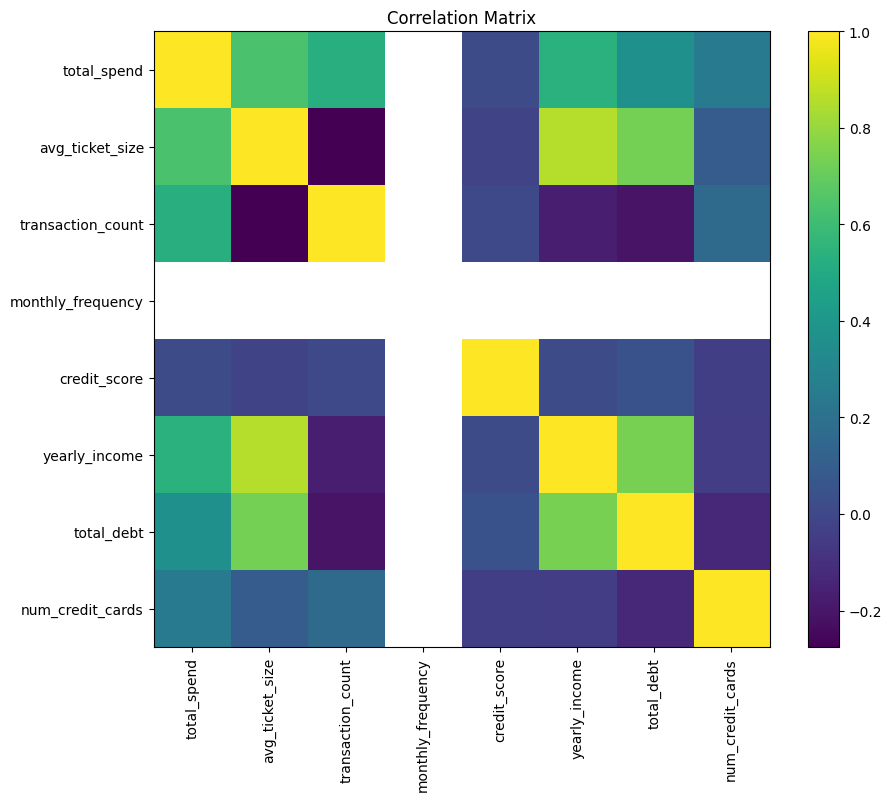

In [81]:
plt.figure(figsize=(10,8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Matrix')

plt.show()

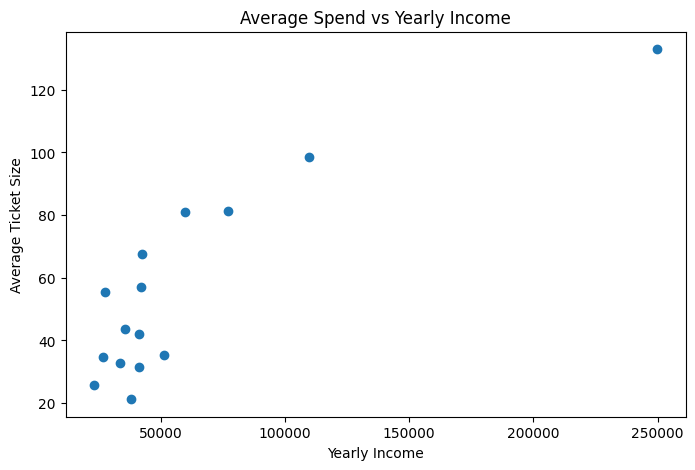

In [82]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_profile['yearly_income'],
    customer_profile['avg_ticket_size']
)

plt.xlabel('Yearly Income')
plt.ylabel('Average Ticket Size')

plt.title(
    'Average Spend vs Yearly Income'
)

plt.show()

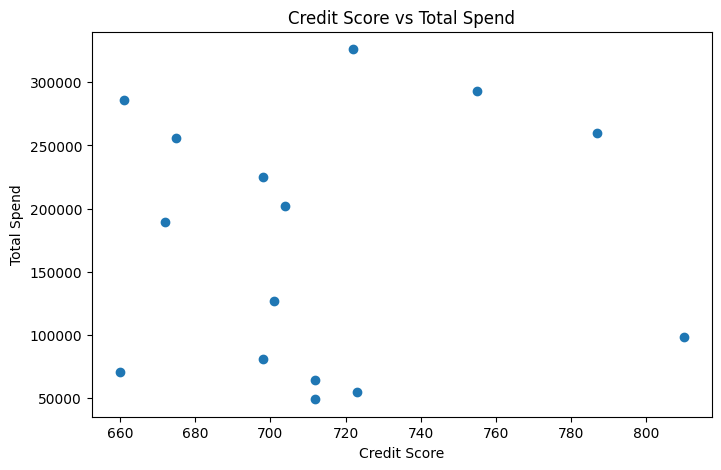

In [83]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_profile['credit_score'],
    customer_profile['total_spend']
)

plt.xlabel('Credit Score')
plt.ylabel('Total Spend')
plt.title('Credit Score vs Total Spend')

plt.show()

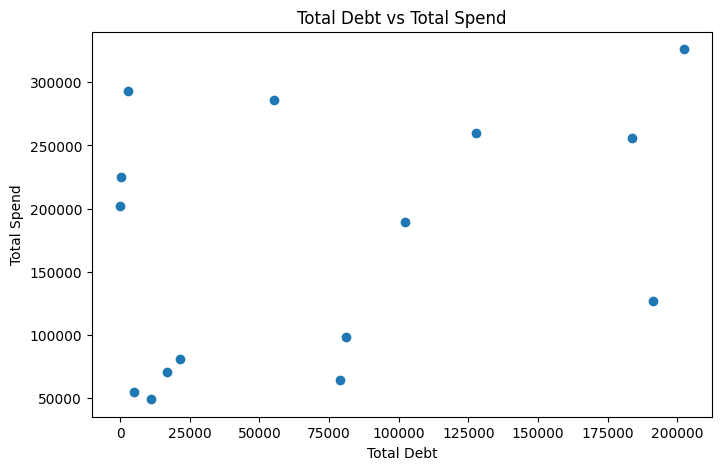

In [84]:
plt.figure(figsize=(8,5))

plt.scatter(
    customer_profile['total_debt'],
    customer_profile['total_spend']
)

plt.xlabel('Total Debt')
plt.ylabel('Total Spend')
plt.title('Total Debt vs Total Spend')

plt.show()

# Task B4: Age Portfolio

## Objective

Analyze customer demographics using age bands.

The analysis includes:

1. Distribution of customers across age bands.
2. Average credit limit by age band.
3. Relationship between age, income, and credit score.
4. Relationship between age and transaction behavior.
5. Determine whether younger customers are more online-transaction oriented.

In [85]:

users['current_age'].describe()


count    25.000000
mean     46.560000
std      20.031392
min      18.000000
25%      29.000000
50%      43.000000
75%      63.000000
max      81.000000
Name: current_age, dtype: float64

In [86]:
users['current_age'].value_counts().sort_index()

current_age
18    2
22    1
26    1
27    1
28    1
29    1
34    2
36    1
41    1
42    1
43    1
45    1
48    1
53    2
54    1
63    1
66    1
70    1
76    2
81    2
Name: count, dtype: int64

In [87]:
users['age_band'] = pd.cut(
    users['current_age'],
    bins=[18, 30, 45, 60, 100],
    labels=[
        '18-29',
        '30-44',
        '45-59',
        '60+'
    ],
    right=False
)

users[['current_age', 'age_band']].head()

,current_age,age_band
0,53,45-59
1,53,45-59
2,81,60+
3,63,60+
4,43,30-44


In [88]:
age_distribution = (
    users['age_band']
    .value_counts()
    .sort_index()
)

age_distribution

age_band
18-29    7
30-44    6
45-59    5
60+      7
Name: count, dtype: int64

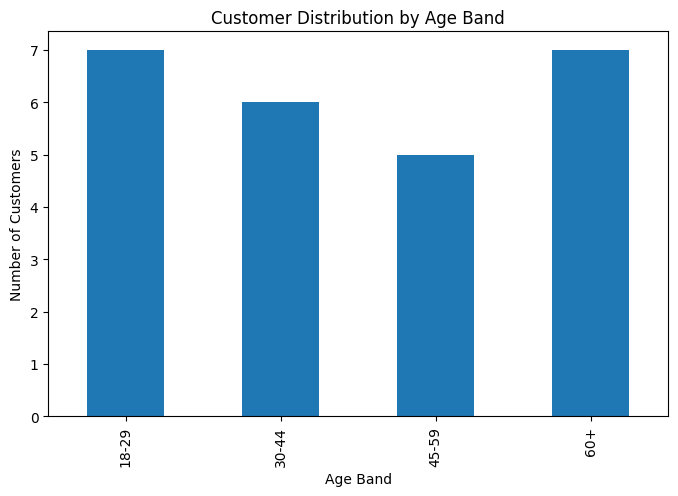

In [89]:
plt.figure(figsize=(8,5))

age_distribution.plot(kind='bar')

plt.title('Customer Distribution by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Number of Customers')

plt.show()

## Insights: Customer Distribution

The customer base is distributed across multiple age groups, providing a diversified portfolio.

Understanding age concentration helps tailor product offerings and marketing campaigns to different customer segments.

In [90]:
age_credit = (
    cards
    .merge(
        users[['id', 'age_band']],
        left_on='client_id',
        right_on='id',
        how='left'
    )
)

age_credit.head()

,id_x,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,id_y,age_band
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,24295.0,09/2002,2008,No,825,45-59
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,21968.0,04/2014,2014,No,825,45-59
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,46414.0,07/2003,2004,No,825,45-59
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,12400.0,01/2003,2012,No,825,45-59
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,28.0,09/2008,2009,No,825,45-59


In [92]:
credit_by_age = (
    age_credit
    .groupby('age_band')['credit_limit']
    .mean()
)

credit_by_age

/var/folders/0z/_kmc5z3524bfrdqt6lz6vsp40000gn/T/ipykernel_20990/107657163.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_credit


age_band
18-29    24836.846154
30-44    12783.941176
45-59    15102.111111
60+      28256.444444
Name: credit_limit, dtype: float64

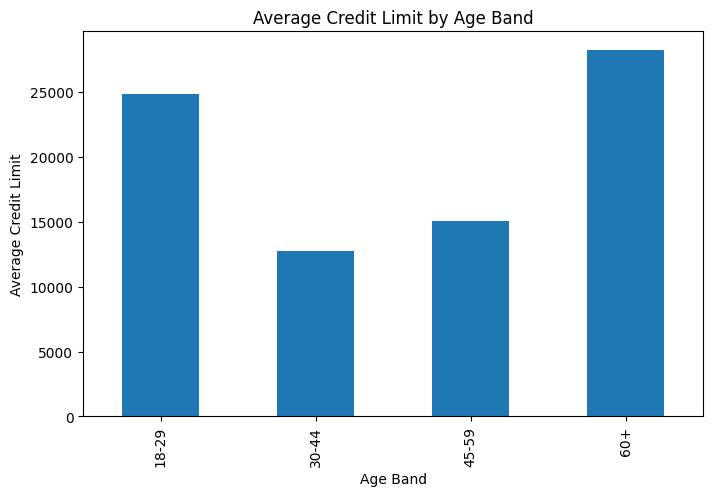

In [93]:
plt.figure(figsize=(8,5))

credit_by_age.plot(kind='bar')

plt.title('Average Credit Limit by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Average Credit Limit')

plt.show()

## Insights: Credit Limit by Age Band

Older customers often receive higher credit limits due to:

- Longer credit history
- Greater financial stability
- Higher repayment reliability

Comparing average credit limits across age groups helps identify premium customer segments.

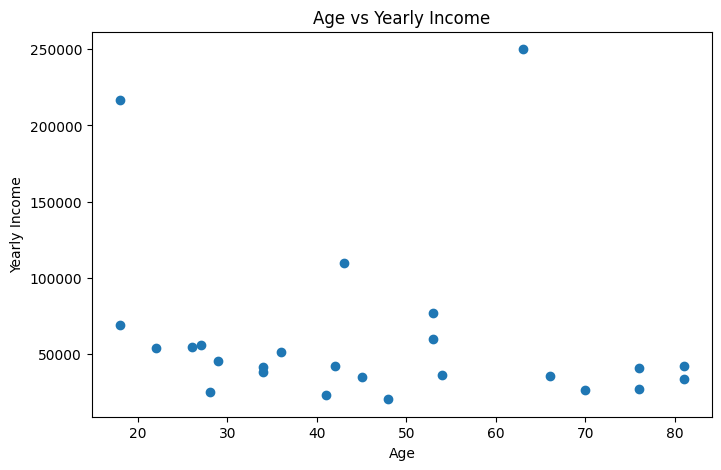

In [95]:
plt.figure(figsize=(8,5))

plt.scatter(
    users['current_age'],
    users['yearly_income']
)

plt.xlabel('Age')
plt.ylabel('Yearly Income')

plt.title('Age vs Yearly Income')

plt.show()

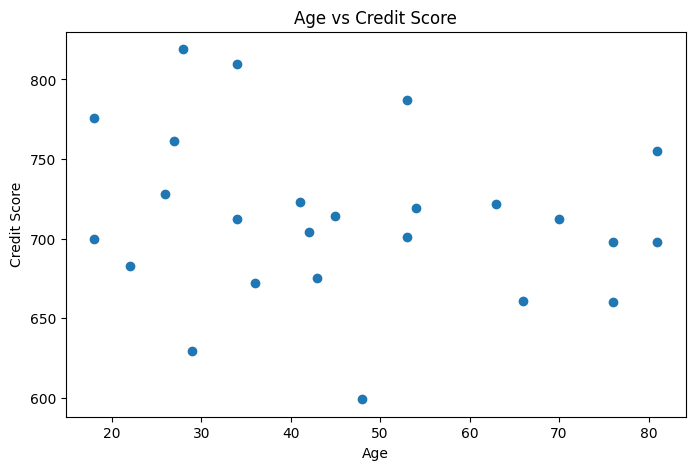

In [96]:
plt.figure(figsize=(8,5))

plt.scatter(
    users['current_age'],
    users['credit_score']
)

plt.xlabel('Age')
plt.ylabel('Credit Score')

plt.title('Age vs Credit Score')

plt.show()

## Insights: Age, Income and Credit Score

These visualizations help evaluate whether:

- Older customers earn higher incomes.
- Creditworthiness improves with age.
- Certain age groups represent lower risk profiles.

Understanding these relationships supports credit policy and customer segmentation decisions.

In [97]:
customer_spend = (
    transactions
    .groupby('client_id')
    .agg(
        total_spend=('amount', 'sum'),
        avg_spend=('amount', 'mean')
    )
    .reset_index()
)

In [98]:
age_spend = (
    customer_spend
    .merge(
        users[
            ['id', 'current_age', 'age_band']
        ],
        left_on='client_id',
        right_on='id',
        how='left'
    )
)

age_spend.head()

,client_id,total_spend,avg_spend,id,current_age,age_band
0,68,202013.82,57.098310,68,42,30-44
1,153,70806.08,55.447204,153,76,60+
2,511,285794.61,43.646092,511,66,60+
3,708,326179.31,132.917404,708,63,60+
4,825,259484.68,81.088962,825,53,45-59


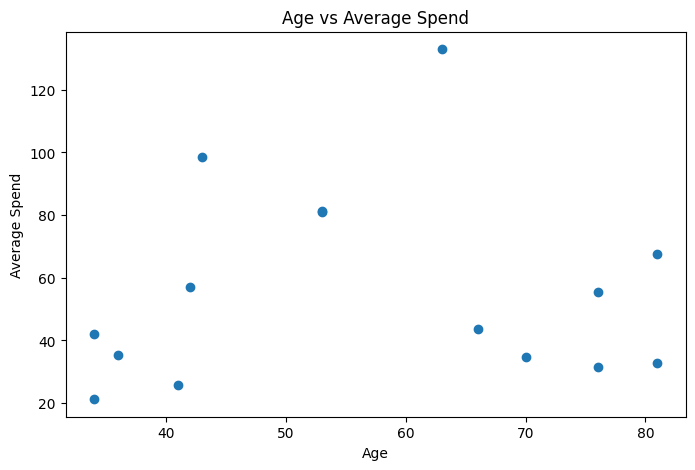

In [99]:
plt.figure(figsize=(8,5))

plt.scatter(
    age_spend['current_age'],
    age_spend['avg_spend']
)

plt.xlabel('Age')
plt.ylabel('Average Spend')

plt.title('Age vs Average Spend')

plt.show()

In [100]:
age_transaction = (
    transactions
    .merge(
        users[['id', 'age_band']],
        left_on='client_id',
        right_on='id',
        how='left'
    )
)

In [101]:
online_usage = pd.crosstab(
    age_transaction['age_band'],
    age_transaction['use_chip'],
    normalize='index'
) * 100

online_usage.round(2)

use_chip,online,swipe
age_band,,
30-44,12.94,87.06
45-59,6.58,93.42
60+,20.16,79.84


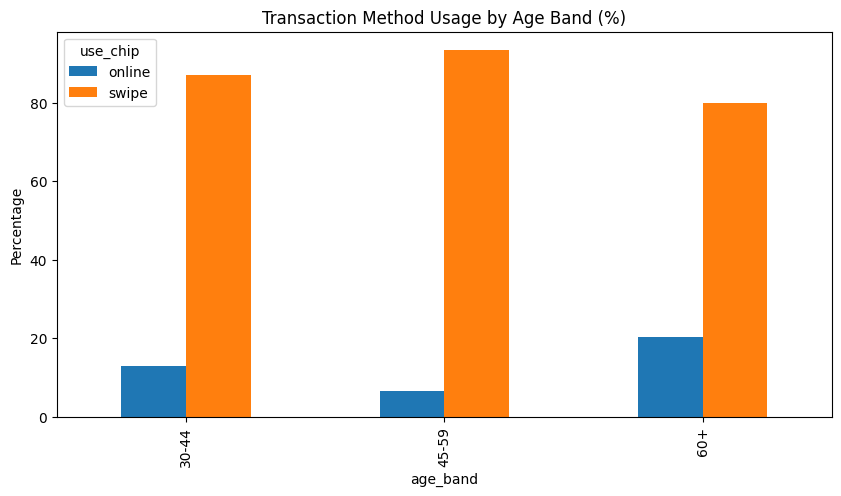

In [102]:
online_usage.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Transaction Method Usage by Age Band (%)'
)

plt.ylabel('Percentage')

plt.show()

## Insights: Are Young Customers Online Heavy?

The transaction method distribution shows how payment preferences differ by age group.

As per above bar chart, 60+ age people are more online heavy than young generation. The young generation more rely on swipe mode.

# Task B5:    Gender analysis



In [104]:
users['gender'].value_counts()

gender
Male      13
Female    12
Name: count, dtype: int64

In [105]:
transactions.merge(
    users[['id', 'gender']],
    left_on='client_id',
    right_on='id'
)['gender'].value_counts()

gender
Female    31817
Male      18183
Name: count, dtype: int64

In [106]:
gender_txn = (
    transactions
    .merge(
        users[['id', 'gender']],
        left_on='client_id',
        right_on='id',
        how='left'
    )
)

gender_txn.head()

,id_x,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors,year_month,id_y,gender
0,7475509,2010-01-01 04:45:00,1718,4706,46.21,online,15143,Online,NAN,00000,4784,No Error,2010-01,1718,Female
1,7475582,2010-01-01 06:03:00,511,974,3.33,swipe,20519,Phoenix,AZ,85015,5942,No Error,2010-01,511,Male
2,7475752,2010-01-01 06:52:00,1718,2029,10.60,swipe,20519,Spring Valley,CA,91977,5942,No Error,2010-01,1718,Female
3,7475819,2010-01-01 07:08:00,511,1038,21.50,swipe,79038,Phoenix,AZ,85015,7538,No Error,2010-01,511,Male
4,7475828,2010-01-01 07:09:00,1094,3755,80.00,swipe,27092,Boyne City,MI,49712,4829,No Error,2010-01,1094,Male


In [107]:
avg_amount_gender = (
    gender_txn
    .groupby('gender')['amount']
    .mean()
)

avg_amount_gender

gender
Female    51.678074
Male      51.573033
Name: amount, dtype: float64

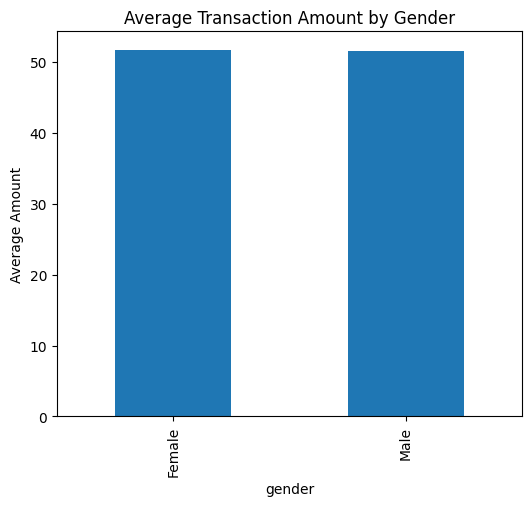

In [108]:
plt.figure(figsize=(6,5))

avg_amount_gender.plot(kind='bar')

plt.title('Average Transaction Amount by Gender')
plt.ylabel('Average Amount')

plt.show()

In [109]:
gender_txn['day_of_week'] = (
    gender_txn['date']
    .dt.day_name()
)

In [110]:
day_gender = pd.crosstab(
    gender_txn['day_of_week'],
    gender_txn['gender']
)

day_gender

gender,Female,Male
day_of_week,,
Friday,4563,2587
Monday,4693,2571
Saturday,4302,2596
Sunday,4388,2586
Thursday,4788,2685
Tuesday,4592,2578
Wednesday,4491,2580


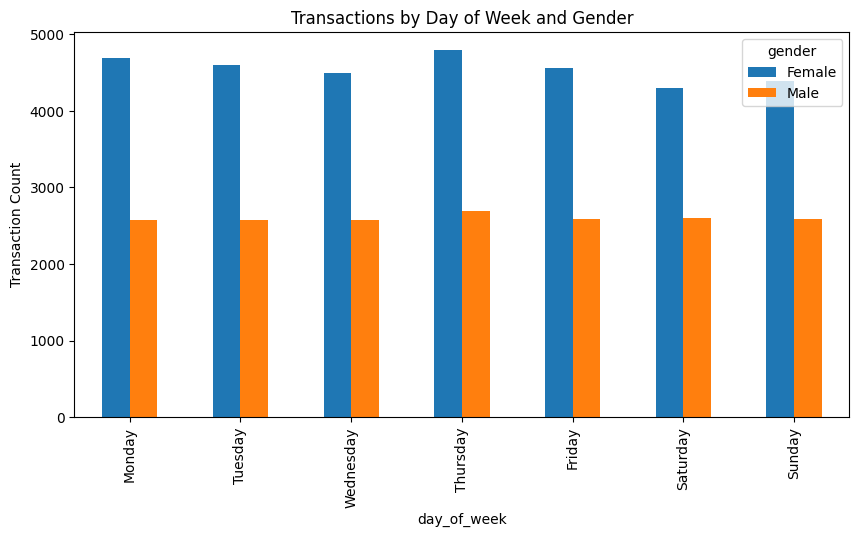

In [111]:
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_gender = day_gender.reindex(day_order)

day_gender.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Transactions by Day of Week and Gender')
plt.ylabel('Transaction Count')

plt.show()

In [112]:
gender_txn['hour'] = (
    gender_txn['date']
    .dt.hour
)

In [113]:
def get_time_period(hour):

    if 5 <= hour < 12:
        return 'Morning'

    elif 12 <= hour < 17:
        return 'Afternoon'

    elif 17 <= hour < 22:
        return 'Evening'

    else:
        return 'Night'


gender_txn['time_period'] = (
    gender_txn['hour']
    .apply(get_time_period)
)

In [114]:
time_gender = pd.crosstab(
    gender_txn['time_period'],
    gender_txn['gender']
)

time_gender

gender,Female,Male
time_period,,
Afternoon,12501,8155
Evening,3625,3223
Morning,13044,6330
Night,2647,475


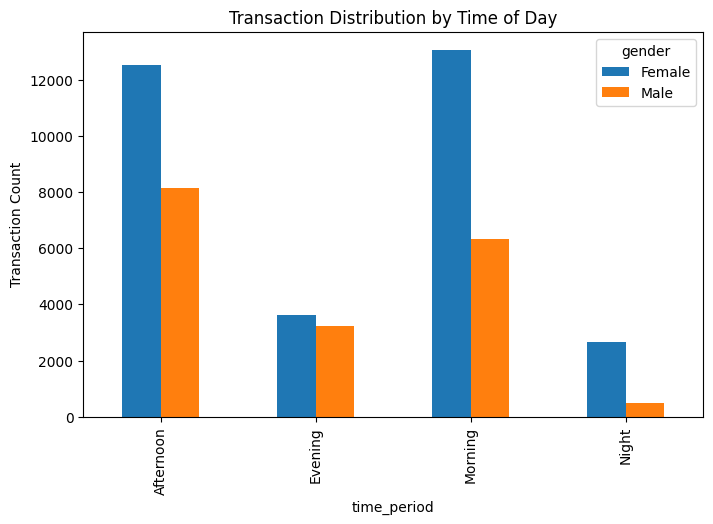

In [115]:
time_gender.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Transaction Distribution by Time of Day')
plt.ylabel('Transaction Count')

plt.show()

In [116]:
gender_txn['is_weekend'] = (
    gender_txn['date']
    .dt.dayofweek >= 5
)

weekend_gender = pd.crosstab(
    gender_txn['is_weekend'],
    gender_txn['gender']
)

weekend_gender.index = [
    'Weekday',
    'Weekend'
]

weekend_gender

gender,Female,Male
Weekday,23127,13001
Weekend,8690,5182


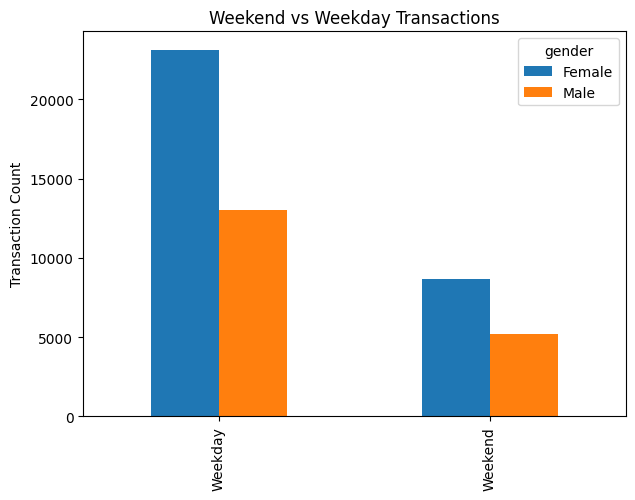

In [117]:
weekend_gender.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Weekend vs Weekday Transactions')
plt.ylabel('Transaction Count')

plt.show()

# Marketing Recommendations

Based on Gender Analysis:

### For Female Customers

- Female customers account for a larger share of transactions.
- Introduce loyalty programs focused on engagement and retention.
- Provide personalized rewards for frequent shoppers.

### For Male Customers

- Promote spending incentives and category-specific offers.
- Encourage increased card usage through cashback programs.

### Timing-Based Campaigns

- Schedule campaigns during peak transaction periods.
- Offer weekend-specific promotions for active customer groups.
- Use digital notifications during high-engagement hours.